In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.dataset_manager import BinaryDatasetManager
from src.utils import RESULTS_DIR

In [2]:
data_manager = BinaryDatasetManager()

data_comphrasion_df = data_manager.df[
    [
        "ratio (0 : 1)",
        "shape",
        "inbalance strength",
        "class negative num",
        "class positive num",
    ]
]
data_comphrasion_df = data_comphrasion_df.assign(
    is_large=data_comphrasion_df.index.map(lambda x: x in data_manager.LARGE_DATASETS),
    is_additional=data_comphrasion_df.index.map(
        lambda x: x in data_manager.additional_datasets
    ),
)
data_comphrasion_df

2025-06-09 00:23:49,309 - src.dataset_manager - INFO - Fetching datasets from imbalanced-learn...
2025-06-09 00:23:49,571 - src.dataset_manager - INFO - Fetching additional datasets...
2025-06-09 00:24:01,782 - src.dataset_manager - INFO - Preparing datasets...


,ratio (0 : 1),shape,inbalance strength,class negative num,class positive num,is_large,is_additional
Breast Cancer Wisconsin (Diagnostic),357:212,"(569, 30)",1.68,357,212,False,True
Ionosphere,14:25,"(351, 34)",1.79,126,225,False,True
Pima Indians Diabetes,125:67,"(768, 8)",1.87,500,268,False,True
ecoli,43:5,"(336, 7)",8.60,301,35,False,False
optical_digits,2533:277,"(5620, 64)",9.14,5066,554,False,False
satimage,5809:626,"(6435, 36)",9.28,5809,626,False,False
pen_digits,9937:1055,"(10992, 16)",9.42,9937,1055,False,False
abalone,3786:391,"(4177, 10)",9.68,3786,391,False,False
sick_euthyroid,2870:293,"(3163, 42)",9.80,2870,293,False,False
spectrometer,54:5,"(531, 93)",10.80,486,45,False,False


In [3]:
pd.crosstab(data_comphrasion_df["is_large"], data_comphrasion_df["is_additional"])

is_additional,False,True
is_large,,
False,24,3
True,3,1


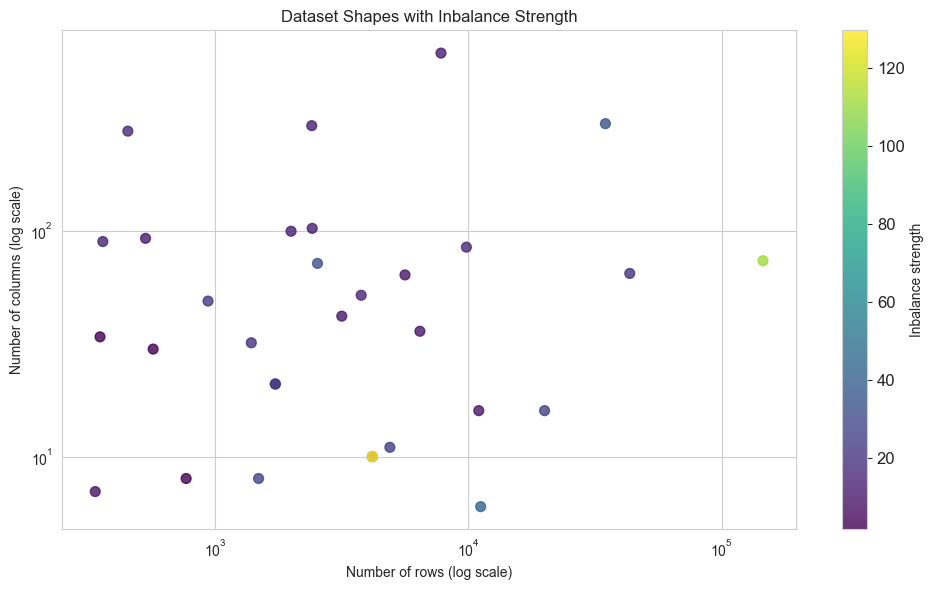

In [4]:
sns.set_style(style="whitegrid")
plt.figure(figsize=(10, 6))

rows = data_comphrasion_df["shape"].apply(lambda s: s[0])
cols = data_comphrasion_df["shape"].apply(lambda s: s[1])

scatter = plt.scatter(
    rows,
    cols,
    c=data_comphrasion_df["inbalance strength"],
    cmap="viridis",
    s=50,
    alpha=0.8,
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of rows (log scale)")
plt.ylabel("Number of columns (log scale)")
plt.title("Dataset Shapes with Inbalance Strength")

cbar = plt.colorbar(scatter, label="Inbalance strength")
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [5]:
data_comphrasion_df.to_latex(
    os.path.join(RESULTS_DIR, "data_comphrasion_df.tex"),
    float_format="%.2f",
    column_format="lcccc",
    escape=False,
)